**Project:** Extended State Estimation  
**Author:** Marin Dagron  
**Date:** January 2026  
**Context:** Industrial Project - CentraleSupélec  

---

## Description
This notebook implements a **Kalman Filter** to estimate the dynamic state of a power system (generators G1 and G2).

The objective is to reconstruct state variables from noisy measurements, in the presence of various load disturbances.

**Document Structure:**
1.  **Modeling:** Definition of system matrices and disturbances.
2.  **Algorithm:** Implementation of the filter's prediction/correction loop.
3.  **Simulation:** Generation of synthetic data (Ground Truth vs Measurements).
4.  **Analysis:** Comparison of estimated vs real states and calculation of the Signal-to-Noise Ratio (SNR).


--- 




### 1. Perturbation senarios 


In [11]:
def get_disturbances(t, scenario, params):
    # Default values (Table 4.1 / Sections 4.2 & 4.3)
    p1l, p2l = params['g1']['PL'], params['g2']['PL'] # 400 and 600 MW 
    kl = params['KL'] # 3064 MW/rad

    if scenario == 'EL1': # Linear increase: 100 MW over 60s
        p1l = 400 + (100 / 60) * min(t, 30)
    elif scenario == 'EL2': # Linear increase: 200 MW over 60s
        p1l = 400 + (200 / 60) * min(t, 60)
    elif scenario == 'SL1': # Load step at 15s: 500 MW
        if t >= 15: p1l = 500
    elif scenario == 'SL2': # Load step at 15s: 600 MW
        if t >= 15: p1l = 600
    elif scenario == 'PLT': # Line trip at 15s
        if t >= 15: kl = 1532 # Change from 3064 to 1532 MW/rad

    return p1l, p2l, kl

### 2. Row model simulation 

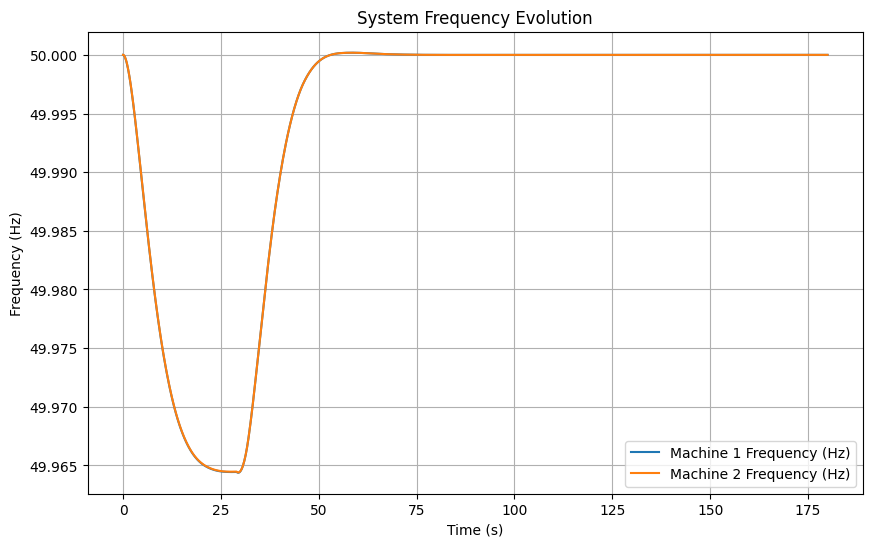

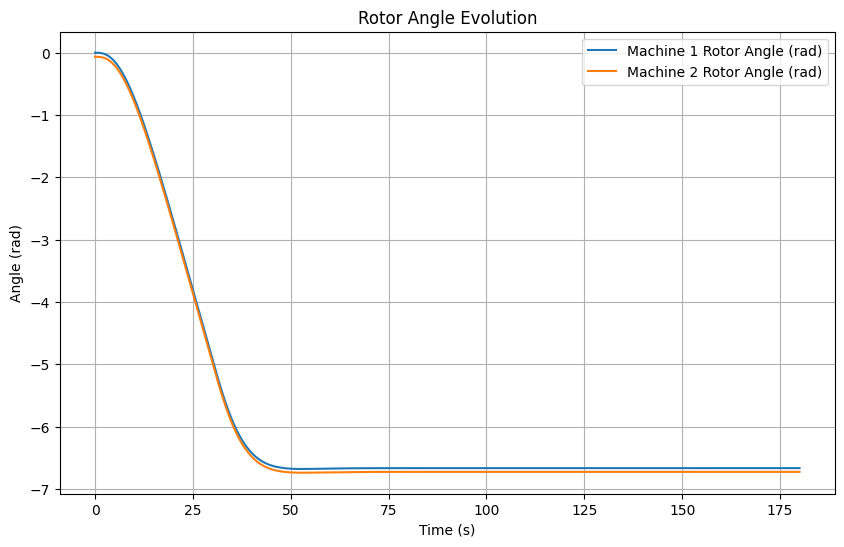

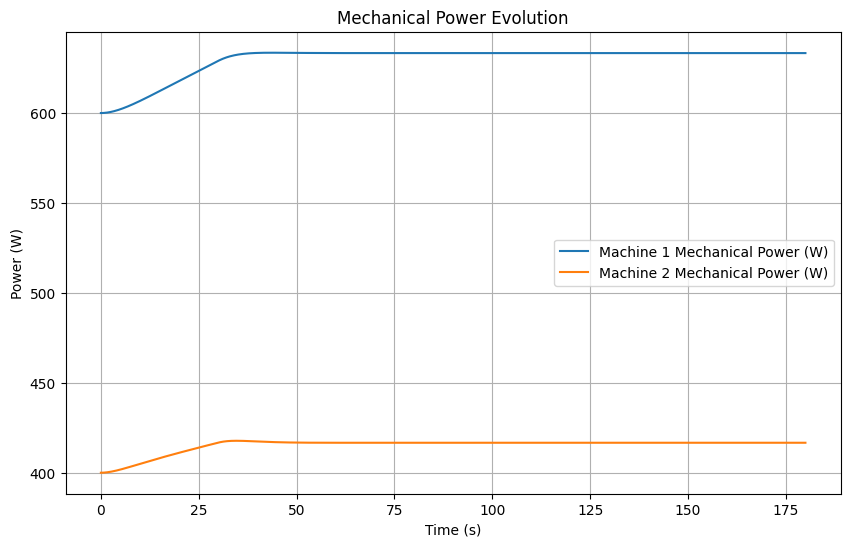

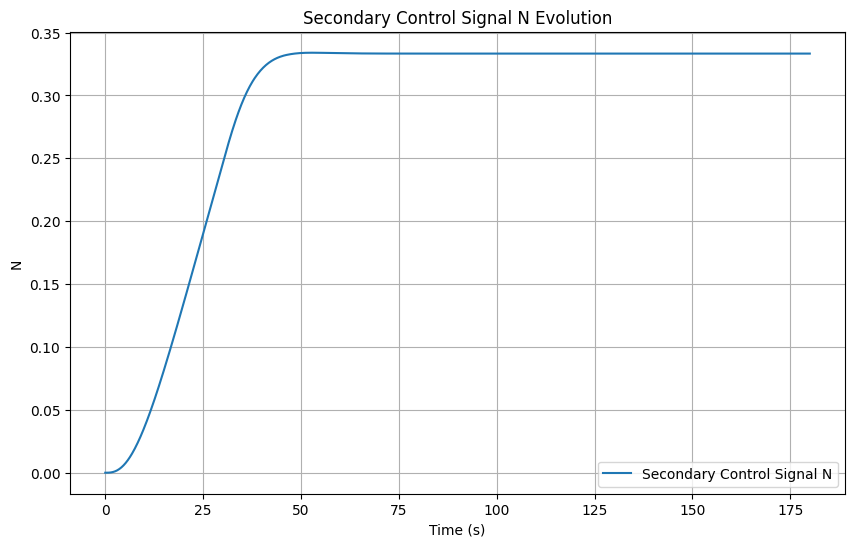

In [12]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def power_system_model(t, x, params):
    
    theta1, omega1, T1m, theta2, omega2, T2m, N = x
    # Ensure get_disturbances is defined in your scope or imported
    p1l , p2l, kl = get_disturbances(t, params['scenario'], params)
    w0 = params['omega0']
    
    # --- Algebraic Equations ---
    # Exchanged Power (Line)
    F12 = kl * np.sin(theta1 - theta2)
    F21 = -F12
    
    # Power demand on generators (Load + Line)
    P1G = p1l + F12
    P2G = p2l + F21

    # Current mechanical power
    P1m = T1m * omega1
    P2m = T2m * omega2
    
    # Power Setpoint (Secondary control N included)
    P1c = np.clip(params['g1']['P0'] + N * params['g1']['Pr'], params['g1']['Pmin'], params['g1']['Pmax'])
    P2c = np.clip(params['g2']['P0'] + N * params['g2']['Pr'], params['g2']['Pmin'], params['g2']['Pmax'])

    # --- Differential Equations ---
    # Generator 1
    d_theta1 = omega1 - w0
    d_omega1 = (T1m - (P1G/omega1) - params['g1']['D']*(omega1 - w0)) / params['g1']['J']
    
    # G1 Primary Control (with saturation limits)
    if params['g1']['Pmin'] <= P1m <= params['g1']['Pmax']:
        d_T1m = -params['g1']['alpha'] * (P1m - P1c) - params['g1']['beta'] * (omega1 - w0)
    else:
        d_T1m = 0

    # Generator 2
    d_theta2 = omega2 - w0
    d_omega2 = (T2m - (P2G/omega2) - params['g2']['D']*(omega2 - w0)) / params['g2']['J']
    
    # G2 Primary Control
    if params['g2']['Pmin'] <= P2m <= params['g2']['Pmax']:
        d_T2m = -params['g2']['alpha'] * (P2m - P2c) - params['g2']['beta'] * (omega2 - w0)
    else:
        d_T2m = 0

    # Secondary Control (Weighted average frequency)
    omega_r = (params['g1']['J']*omega1 + params['g2']['J']*omega2) / (params['g1']['J'] + params['g2']['J'])
    if -1 <= N <= 1:
        dN = -params['Ks'] * (omega_r - w0)
    else:
        dN = 0

    return [d_theta1, d_omega1, d_T1m, d_theta2, d_omega2, d_T2m, dN]

# --- System Parameters ---
w0_rad = 2 * np.pi * 50
params = {
    'f0': 50.0,
    'omega0': 2 * np.pi * 50.0,
    'KL': 3064.0,   # MW/rad (two lines)
    'Ks': 0.05,
    'g1': {
        'P0': 600.0, 'Pmin': 0.0, 'Pmax': 1000.0, 'Pr': 100.0,
        'J': 0.4, 'D': 0.04, 'alpha': 100.0, 'beta': 2000.0, 'PL': 400.0
    },
    'g2': {
        'P0': 400.0, 'Pmin': 0.0, 'Pmax': 600.0, 'Pr': 50.0,
        'J': 0.1, 'D': 0.02, 'alpha': 100.0, 'beta': 2000.0, 'PL': 600.0
    },
    't_event': 15.0,
    'scenario':  'EL1' # Choices: 'EL1', 'EL2', 'SL1', 'SL2', 'PLT'
}


#--- Simulation ---
# Initial Conditions
# Equilibrium position
x0 = [0, w0_rad, params['g1']['P0']/w0_rad, -np.arcsin((params['g1']['P0'] - params['g1']['PL']) / params['KL']), w0_rad, params['g2']['P0']/w0_rad, 0] 
# Small initial perturbation (on theta2) - commented out
# x0 = [0, w0_rad, params['g1']['P0']/w0_rad, 0, w0_rad, params['g2']['P0']/w0_rad, 0] 

t_span = (0, 180)
t_eval = np.linspace(0, t_span[1], 1000)

sol = solve_ivp(power_system_model, t_span, x0, args=(params,), t_eval=t_eval, method='Radau')

theta1_sim = sol.y[0]
theta2_sim = sol.y[3]
F12_sim = params['KL'] * (theta1_sim - theta2_sim)
P1G_sim = params['g1']['PL'] + F12_sim
P2G_sim = params['g2']['PL'] + F12_sim

# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[1]/(2*np.pi), label='Machine 1 Frequency (Hz)')
plt.plot(sol.t, sol.y[4]/(2*np.pi), label='Machine 2 Frequency (Hz)')
plt.title("System Frequency Evolution")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label='Machine 1 Rotor Angle (rad)')
plt.plot(sol.t, sol.y[3], label='Machine 2 Rotor Angle (rad)')
plt.title("Rotor Angle Evolution")    
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[2]*sol.y[1], label='Machine 1 Mechanical Power (W)')
plt.plot(sol.t, sol.y[5]*sol.y[4], label='Machine 2 Mechanical Power (W)')
plt.title("Mechanical Power Evolution")       
plt.xlabel("Time (s)")
plt.ylabel("Power (W)")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[6], label='Secondary Control Signal N')
plt.title("Secondary Control Signal N Evolution")       
plt.xlabel("Time (s)")
plt.ylabel("N")
plt.grid(True)
plt.legend()
plt.show()

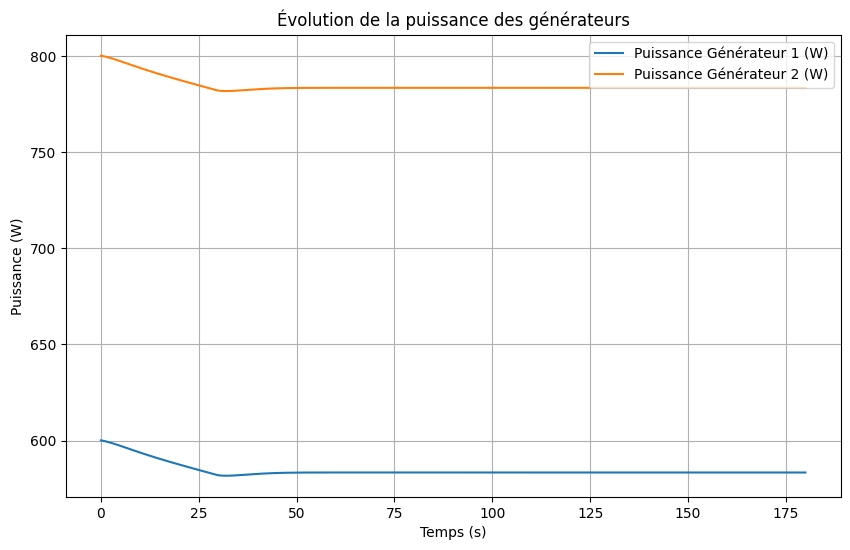

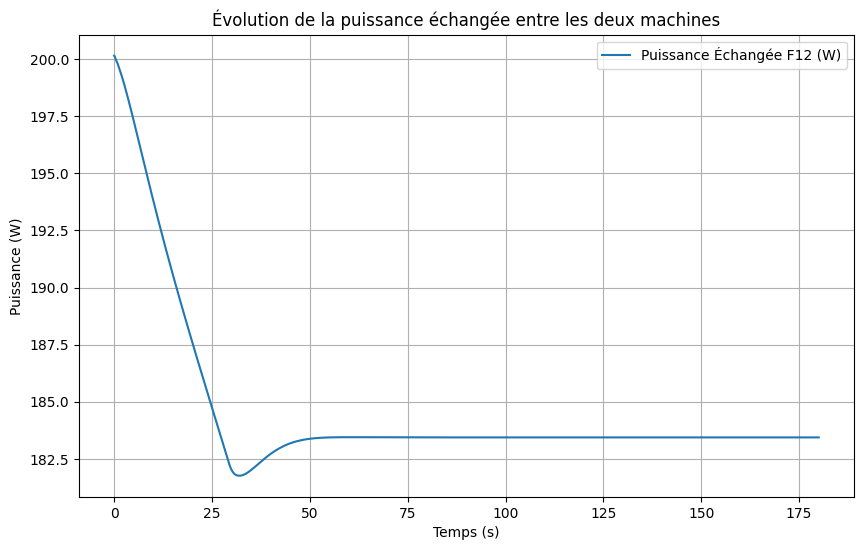

In [13]:
plt.figure(figsize=(10, 6)) 
plt.plot(sol.t, P1G_sim, label='Puissance Générateur 1 (W)')
plt.plot(sol.t, P2G_sim, label='Puissance Générateur 2 (W)')
plt.title("Évolution de la puissance des générateurs")  
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol.t, F12_sim, label='Puissance Échangée F12 (W)')
plt.title("Évolution de la puissance échangée entre les deux machines")
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.grid(True)
plt.legend()
plt.show()

In [14]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.integrate import solve_ivp

# # ==========================================================
# # 1. Configuration des Paramètres (Tableau 4.1 & Notebook)
# # ==========================================================
# params = {
#     'f0': 50.0,
#     'omega0': 2 * np.pi * 50.0,
#     'KL_nom': 3064.0,   # MW/rad (deux lignes)
#     'KL_one': 1532.0,   # Une seule ligne
#     'Ks': 0.05,
#     'g1': {
#         'P0': 600.0, 'Pmin': 0.0, 'Pmax': 1000.0, 'Pr': 100.0,
#         'J': 0.4, 'D': 0.04, 'alpha': 100.0, 'beta': 2000.0, 'PL0': 400.0
#     },
#     'g2': {
#         'P0': 400.0, 'Pmin': 0.0, 'Pmax': 600.0, 'Pr': 50.0,
#         'J': 0.1, 'D': 0.02, 'alpha': 100.0, 'beta': 2000.0, 'PL0': 600.0
#     },
#     't_event': 15.0,
#     'scenario': 'loadRamp1' # Choix : 'loadRamp1', 'loadRamp2', 'loadStep1', 'loadStep2', 'lineTrip'
# }

# # ==========================================================
# # 2. Définition du Système Différentiel (ODE)
# # ==========================================================
# def power_system_ode(t, x, p):
#     # Désassemblage du vecteur d'état X
#     theta1, theta2, w1, w2, Tm1, Tm2, N = x
#     w0 = p['omega0']
    
#     # --- Gestion des Événements (Disturbances) ---
#     delta_PL1 = 0.0
#     KL = p['KL_nom']
    
#     sc = p['scenario']
#     if sc == 'loadRamp1':
#         delta_PL1 = 100 / 60 # +100MW en 1min
#     elif sc == 'loadRamp2':
#         delta_PL1 = 200 / 60
#     elif sc == 'loadStep1' and t >= p['t_event']:
#         PL1 = 500.0 # Échelon à 500MW
#     elif sc == 'loadStep2' and t >= p['t_event']:
#         PL1 = 600.0 # Échelon à 600MW
#     elif sc == 'lineTrip' and t >= p['t_event']:
#         KL = p['KL_one']

#     # --- Équations Algébriques ---
#     dPL1 = delta_PL1 if sc.startswith('loadRamp') else 0.0
#     PL1 = p['g1']['PL0'] + dPL1*t
#     F12 = KL * np.sin(theta1 - theta2)
#     PG1 = PL1 + F12
#     PG2 = p['g2']['PL0'] - F12
    
#     # Fréquence centrale
#     wr = (p['g1']['J']*w1 + p['g2']['J']*w2) / (p['g1']['J'] + p['g2']['J'])

#     # --- Équations Différentielles ---
#     # Contrôle Secondaire (N)
#     dN = -p['Ks']*(wr - w0) if abs(N) <= 1.0 else 0.0
    
#     # Évolution de la charge (Rampes)
#     dPL1 = delta_PL1 if sc.startswith('loadRamp') else 0.0
#     dPL2 = 0.0

#     # Machine 1
#     Pc1 = np.clip(p['g1']['P0'] + N * p['g1']['Pr'], p['g1']['Pmin'], p['g1']['Pmax'])
#     Pm1 = Tm1 * w1
#     dTm1 = -p['g1']['alpha']*(Pm1 - Pc1) - p['g1']['beta']*(w1 - w0) if (p['g1']['Pmin'] <= Pm1 <= p['g1']['Pmax']) else 0.0
#     dw1 = (Tm1 - PG1/w1 - p['g1']['D']*(w1 - w0)) / p['g1']['J']
#     dtheta1 = w1 - w0

#     # Machine 2
#     Pc2 = np.clip(p['g2']['P0'] + N * p['g2']['Pr'], p['g2']['Pmin'], p['g2']['Pmax'])
#     Pm2 = Tm2 * w2
#     dTm2 = -p['g2']['alpha']*(Pm2 - Pc2) - p['g2']['beta']*(w2 - w0) if (p['g2']['Pmin'] <= Pm2 <= p['g2']['Pmax']) else 0.0
#     dw2 = (Tm2 - PG2/w2 - p['g2']['D']*(w2 - w0)) / p['g2']['J']
#     dtheta2 = w2 - w0

#     return [dtheta1, dtheta2, dw1, dw2, dTm1, dTm2, dN]

# # ==========================================================
# # 3. Initialisation et Simulation
# # ==========================================================
# # Conditions initiales à l'équilibre (t=0)
# x0 = [
#     0.0,                               # theta1
#     np.arcsin((params['g1']['PL0'] - params['g1']['P0']) / params['KL_nom']), # theta2
#     params['omega0'],                  # w1
#     params['omega0'],                  # w2
#     params['g1']['P0'] / params['omega0'], # Tm1
#     params['g2']['P0'] / params['omega0'], # Tm2
#     0.0,                               # N
# ]

# t_span = (0, 60.0)
# t_eval = np.linspace(0, 60.0, 1000)

# # Utilisation du solveur 'Radau' (recommandé pour les systèmes raides de puissance)
# sol = solve_ivp(power_system_ode, t_span, x0, args=(params,), t_eval=t_eval, method='Radau')

# # ==========================================================
# # 4. Exportation et Visualisation
# # ==========================================================
# # Sauvegarde en CSV
# df = pd.DataFrame(sol.y.T, columns=['theta1', 'theta2', 'w1', 'w2', 'Tm1', 'Tm2', 'N'])
# df['time'] = sol.t
# df.to_csv(f"Res_Sim_{params['scenario']}.csv", index=False)

# # Tracé des résultats
# fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# # Fréquences
# axs[0].plot(sol.t, sol.y[2]/(2*np.pi), label='Gen 1')
# axs[0].plot(sol.t, sol.y[3]/(2*np.pi), label='Gen 2', linestyle='--')
# axs[0].set_ylabel("Fréquence (Hz)")
# axs[0].legend()
# axs[0].grid(True)

# # Puissances Mécaniques
# axs[1].plot(sol.t, sol.y[4]*sol.y[2], label='Pm 1')
# axs[1].plot(sol.t, sol.y[5]*sol.y[3], label='Pm 2', linestyle='--')
# axs[1].set_ylabel("Puissance (MW)")
# axs[1].legend()
# axs[1].grid(True)

# # Niveau de contrôle secondaire
# axs[2].plot(sol.t, sol.y[6], color='red')
# axs[2].set_ylabel("N (Contrôle Secondaire)")
# axs[2].set_xlabel("Temps (s)")
# axs[2].grid(True)

# plt.tight_layout()
# plt.show()

### 3. Linear system modelisation 

In [15]:
import sympy as sp

t1, w1, tm1, t2, w2, tm2, n = sp.symbols('theta1 omega1 Tm1 theta2 omega2 Tm2 N')
p10, p20, pl1, pl2, pg1, pg2, kl, w0, j1, j2, d1, d2, a1, a2, b1, b2, pr1, pr2, ks = sp.symbols(
    'P10 P20 P1L P2L PG1 PG2 KL omega0 J1 J2 D1 D2 alpha1 alpha2 beta1 beta2 Pr1 Pr2 Ks'
)

# ---State vector---
X = sp.Matrix([t1, w1, tm1, t2, w2, tm2, n]) 

# --- System Equations ---
f12 = kl * (t1 - t2) 
pg1 = pl1 + f12
pg2 = pl2 - f12

f = sp.Matrix([
    w1 - w0,
    (tm1 - (pl1 + f12)/w0 - d1*(w1 - w0))/j1,
    -a1*(tm1*w0 - (p10 + n*pr1)) - b1*(w1 - w0),
    w2 - w0,
    (tm2 - (pl2 - f12)/w0 - d2*(w2 - w0))/j2,
    -a2*(tm2*w0 - (p20 + n*pr2)) - b2*(w2 - w0),
    -ks * ((j1*w1 + j2*w2)/(j1+j2) - w0)
])

# --- Outputs ---
Y = sp.Matrix([ t1,f12, pg1, pg2]) 

# --- Compute Jacobians ---
A_sym = f.jacobian(X)
B_sym = f.jacobian(sp.Matrix([p10, p20]))
D_sym = f.jacobian(sp.Matrix([pl1, pl2]))

C_sym = Y.jacobian(X)
E_sym = Y.jacobian(sp.Matrix([pl1, pl2]))

print("Matrix A (First row):", A_sym)
print("Matrix B(First row):", B_sym)
print("Matrix D (First row):", D_sym)
print("Matrix C (First row):", C_sym)
print("Matrix E (First row):", E_sym)

# --- Symbolic to Numeric ---
subs_dict = {
    w0:  params['omega0'],
    kl:  params['KL'], 
    ks:  params['Ks'],
    # Générateur 1
    p10: params['g1']['P0'],
    pl1: params['g1']['PL'],
    j1:  params['g1']['J'],
    d1:  params['g1']['D'],
    a1:  params['g1']['alpha'],
    b1:  params['g1']['beta'],
    pr1: params['g1']['Pr'],
    # Générateur 2
    p20: params['g2']['P0'],
    pl2: params['g2']['PL'],
    j2:  params['g2']['J'],
    d2:  params['g2']['D'],
    a2:  params['g2']['alpha'],
    b2:  params['g2']['beta'],
    pr2: params['g2']['Pr']
}

A_num = np.array(A_sym.subs(subs_dict)).astype(np.float64)
B_num = np.array(B_sym.subs(subs_dict)).astype(np.float64)
C_num = np.array(C_sym.subs(subs_dict)).astype(np.float64)
D_num = np.array(D_sym.subs(subs_dict)).astype(np.float64)
E_num = np.array(E_sym.subs(subs_dict)).astype(np.float64)

print("Numeric A Matrix:\n", A_num)

# --- Numerical Observability Analysis ---
n = A_num.shape[0]

obs_blocks = [C_num @ np.linalg.matrix_power(A_num, i) for i in range(n)]
Obs_matrix = np.vstack(obs_blocks)
print("Observability Matrix:\n", Obs_matrix)
rank_obs = np.linalg.matrix_rank(Obs_matrix, tol=1e-8) # becarfull with tol that can change the result

print(f"Matrice d'observabilité (shape) : {Obs_matrix.shape}")
print(f"Rang de la matrice d'observation : {rank_obs}")
print(f"Dimension de l'état (n) : {n}")

if rank_obs == n:
    print("Le système est observable (rang plein).")
else:
    print(f"Le système n'est PAS observable ({n - rank_obs} modes inobservables).")

Matrix A (First row): Matrix([[0, 1, 0, 0, 0, 0, 0], [-KL/(J1*omega0), -D1/J1, 1/J1, KL/(J1*omega0), 0, 0, 0], [0, -beta1, -alpha1*omega0, 0, 0, 0, Pr1*alpha1], [0, 0, 0, 0, 1, 0, 0], [KL/(J2*omega0), 0, 0, -KL/(J2*omega0), -D2/J2, 1/J2, 0], [0, 0, 0, 0, -beta2, -alpha2*omega0, Pr2*alpha2], [0, -J1*Ks/(J1 + J2), 0, 0, -J2*Ks/(J1 + J2), 0, 0]])
Matrix B(First row): Matrix([[0, 0], [0, 0], [alpha1, 0], [0, 0], [0, 0], [0, alpha2], [0, 0]])
Matrix D (First row): Matrix([[0, 0], [-1/(J1*omega0), 0], [0, 0], [0, 0], [0, -1/(J2*omega0)], [0, 0], [0, 0]])
Matrix C (First row): Matrix([[1, 0, 0, 0, 0, 0, 0], [KL, 0, 0, -KL, 0, 0, 0], [KL, 0, 0, -KL, 0, 0, 0], [-KL, 0, 0, KL, 0, 0, 0]])
Matrix E (First row): Matrix([[0, 0], [0, 0], [1, 0], [0, 1]])
Numeric A Matrix:
 [[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.43825373e+01 -1.00000000e-01  2.50000000e+00  2.43825373e+01
   0.00000000e+00  0.00000000e+00  0.00000000e+0

### 4. Simulation of the linear system using Euler's metod

Senario : EL1


100%|██████████| 5999999/5999999 [01:22<00:00, 73155.75it/s]
C:\Users\marin\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


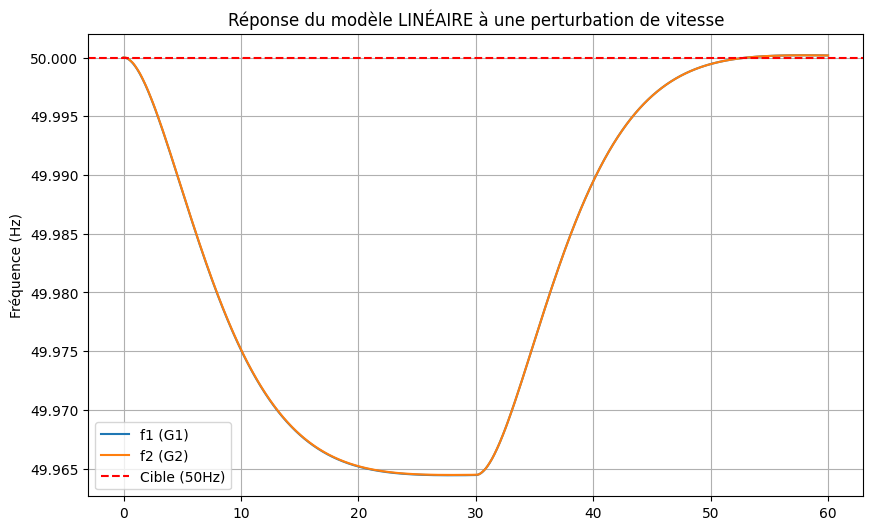

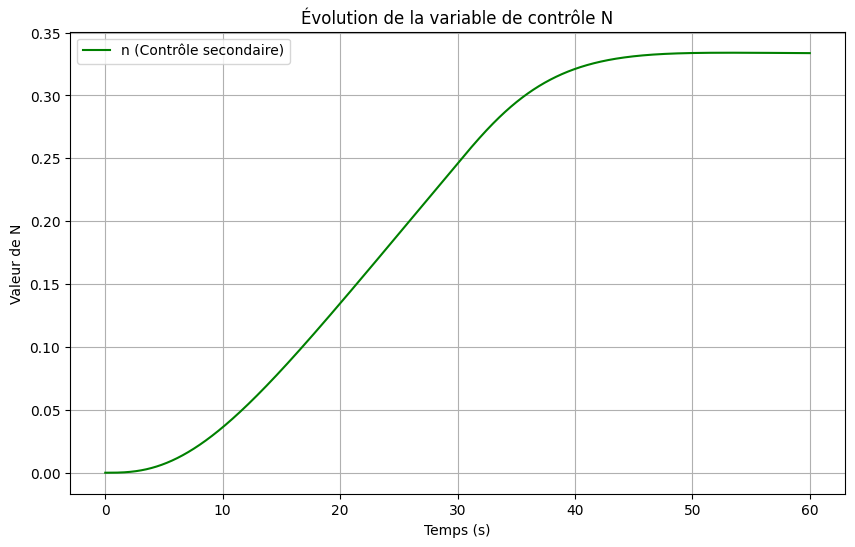

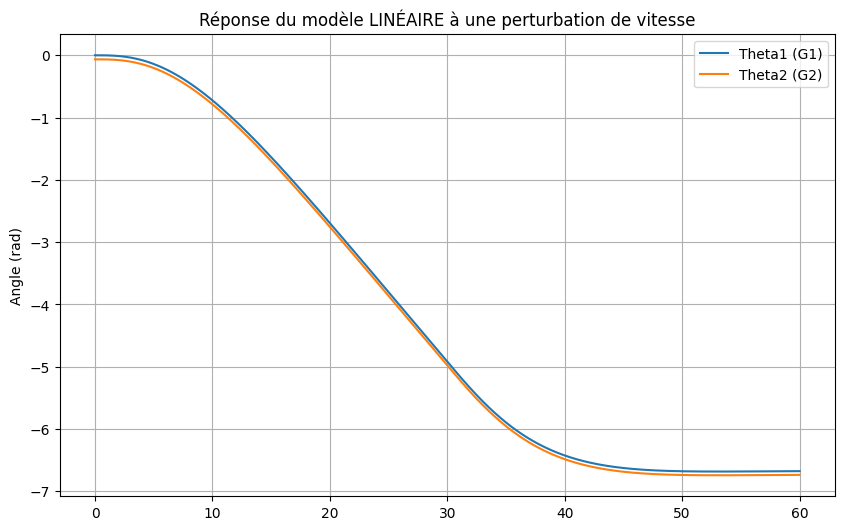

In [16]:

import tqdm

# ---  Initials states ---
x0 = np.array([0, params['omega0'], params['g1']['P0']/params['omega0'], -np.arcsin((params['g1']['P0'] - params['g1']['PL']) / params['KL']), params['omega0'], params['g2']['P0']/params['omega0'], 0]) # equilibrium point
#x0 = np.array([0, params['omega0'], params['g1']['P0']/params['omega0'], 0.0, params['omega0'], params['g2']['P0']/params['omega0'], 0]) # Small perturbation on theta2

# --- Equilibrium state ---
x_eq = np.array([0, params['omega0'], params['g1']['P0']/params['omega0'], -np.arcsin((params['g1']['P0'] - params['g1']['PL']) / params['KL']), params['omega0'], params['g2']['P0']/params['omega0'], 0])
u_eq = np.array([params['g1']['P0'], params['g2']['P0']])
w_eq = np.array([params['g1']['PL'], params['g2']['PL']])

# --- Simulation setup ---
dt = 0.00001  # The time step must be small enough for stability
t_final = 60
t_steps = np.arange(0, t_final, dt)
delta_x0 = x0 - x_eq
x_history = np.zeros((len(t_steps), len(delta_x0)))
x_history[0] = x0
delta_x_current = delta_x0.copy()
delta_u = np.array([0.0, 0.0]) 
delta_w = np.array([0.0, 0.0]) 
print("Senario :", params['scenario'])

# --- Euler's loop ---
for i in tqdm.tqdm(range(1, len(t_steps))):
    
    p1l, p2l, kl = get_disturbances(t_steps[i], params['scenario'], params)
    delta_w = np.array([p1l, p2l]) - w_eq  
    
    d_delta_x_dt = A_num @ delta_x_current + B_num @ delta_u + D_num @ delta_w

    delta_x_current = delta_x_current + d_delta_x_dt * dt
    x_history[i] = delta_x_current + x_eq
    
# --- Post-processing ---
x_final_history = x_history.copy()

x_final_history[:, 1] = x_final_history[:, 1]/(2*np.pi)  # omega1 rad to Hz
x_final_history[:, 4] = x_final_history[:, 4] / (2*np.pi)  # omega2 rad to Hz

y_final_history = np.zeros((len(t_steps), len(Y)))
for i in range(len(t_steps)):
    pl1, pl2, kl = get_disturbances(t_steps[i], params['scenario'], params)
    y_final_history[i, :] = C_num @ x_final_history[i, :] + E_num @ np.array([pl1, pl2])

# --- Visualisation ---
plt.figure(figsize=(10, 6))

plt.plot(t_steps, x_final_history[:, 1], label='f1 (G1)')
plt.plot(t_steps, x_final_history[:, 4], label='f2 (G2)')
plt.axhline(y=params['omega0'] / (2*np.pi), color='r', linestyle='--', label='Cible (50Hz)')
plt.title("Réponse du modèle LINÉAIRE à une perturbation de vitesse")
plt.ylabel("Fréquence (Hz)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_steps, x_final_history[:, 6], label='n (Contrôle secondaire)', color='green')
plt.title("Évolution de la variable de contrôle N")
plt.xlabel("Temps (s)")
plt.ylabel("Valeur de N")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_steps, x_final_history[:, 0], label='Theta1 (G1)')
plt.plot(t_steps, x_final_history[:, 3], label='Theta2 (G2)')
plt.title("Réponse du modèle LINÉAIRE à une perturbation de vitesse")
plt.ylabel("Angle (rad)")
plt.legend()
plt.grid(True)
plt.show()

### 5. Kalman Filter implementation

In [17]:
from tqdm import tqdm

# --- Discretisation ---
Ad = np.eye(len(X)) + A_num * dt
Bd = B_num * dt
Dd = D_num *dt
C_obs = C_num  
E_obs = E_num 

# --- Initialisation ---
delta_x_hat = delta_x0.copy().reshape(-1, 1) 
y_eq = C_obs @ x_eq.reshape(-1, 1) + E_obs @ w_eq.reshape(-1, 1)
P_cov = np.eye(len(X)) * 0.1    # Initial covariance matrix               
delta_x_hat_history = np.zeros((len(t_steps), len(X)))
y_hat_history = np.zeros((len(t_steps), len(Y)))
du = np.zeros((2, 1))  
dw = np.zeros((2, 1)) 

# --- Add noise to measurements ---
x_reel = x_final_history.reshape(-1, 1)
snr_db = 40 # Signal-to-Noise Ratio in dB
signal_power_per_channel = np.mean(y_final_history**2, axis=0)
snr_linear = 10**(snr_db / 10)
noise_power_per_channel = signal_power_per_channel / snr_linear
sigma_noise_per_channel = np.sqrt(noise_power_per_channel)
noise = np.random.normal(0, 1, y_final_history.shape) * sigma_noise_per_channel
y_reel = y_final_history + noise

sigma_noise_pl = np.sqrt([params['g1']['PL']**2 / snr_linear, params['g2']['PL']**2 / snr_linear]) 
print("Sigma Noise P1L, P2L :", sigma_noise_pl)
print("Sigma Noise Y channels :", sigma_noise_per_channel)

# --- Filter parameters ---
Q = np.eye(len(X)) * 1  # Model noise (model confidence)
R = np.eye(len(Y)) * 1e-3  # Measure noise (sensors confidence)
R = np.diag([0.10318252, 1.74723964, 6.49766156, 4.25728592])  # Measure noise (sensors confidence)
# R = np.diag(noise_power_per_channel) # Measure noise (sensors confidence)


#--- Kalman Filter Loop ---
for i in tqdm(range(len(t_steps))):
    p1l, p2l, kl = get_disturbances(t_steps[i], params['scenario'], params)
    delta_w = np.array([p1l+np.random.normal(0, sigma_noise_pl[0]), p2l + np.random.normal(0, sigma_noise_pl[1])]) - w_eq  
    dw = delta_w.reshape(-1, 1)
    delta_y = y_reel[i].reshape(-1, 1) - y_eq

    # --- Prediction ---
    delta_x_hat_minus = Ad @ delta_x_hat + Bd @ du + Dd @ dw
    P_minus = Ad @ P_cov @ Ad.T + Q

    # --- Correction ---
    innovation = delta_y - (C_obs @ delta_x_hat_minus + E_obs @ dw)
    
    S = C_obs @ P_minus @ C_obs.T + R
    K = P_minus @ C_obs.T @ np.linalg.inv(S)
    
    delta_x_hat = delta_x_hat_minus + K @ innovation
    P_cov = (np.eye(7) - K @ C_obs) @ P_minus
    

    delta_x_hat_history[i] = delta_x_hat.flatten()
    
    # --- Estimated output ---
    delta_y_hat = C_obs @ delta_x_hat + E_obs @ dw
    y_hat_total = delta_y_hat + y_eq

    y_hat_history[i] = y_hat_total.flatten()

Sigma Noise P1L, P2L : [4. 6.]
Sigma Noise Y channels : [0.04834478 1.86983278 6.244931   4.13134972]


100%|██████████| 6000000/6000000 [22:24<00:00, 4463.42it/s]


--- SNR de l'estimation des sorties (Post-Kalman) ---
SNR F12 : 41.31 dB
SNR Pg1 : 37.79 dB
SNR Pg2 : 43.69 dB

--- Amélioration apportée par le filtre ---
Gain SNR F12 : +1.31 dB
Gain SNR Pg1 : +-2.21 dB
Gain SNR Pg2 : +3.69 dB


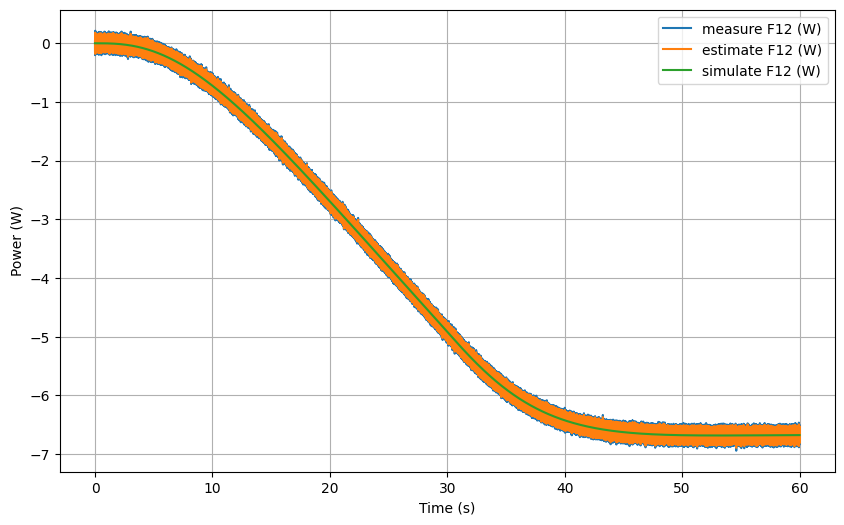

In [18]:
# --- Visualisation --- 
erreur_y = y_final_history - y_hat_history
puissance_signal_y = np.mean(y_final_history**2, axis=0)
puissance_bruit_y = np.mean(erreur_y**2, axis=0)
snr_y_db = 10 * np.log10(puissance_signal_y / puissance_bruit_y)
canaux = ['F12', 'Pg1', 'Pg2']
print("--- SNR de l'estimation des sorties (Post-Kalman) ---")
for i, nom in enumerate(canaux):
    print(f"SNR {nom} : {snr_y_db[i]:.2f} dB")
puissance_bruit_initial = np.mean((y_reel - y_final_history)**2, axis=0)
snr_initial_db = 10 * np.log10(puissance_signal_y / puissance_bruit_initial)
gain_db = snr_y_db - snr_initial_db

print("\n--- Amélioration apportée par le filtre ---")
for i, nom in enumerate(canaux):
    print(f"Gain SNR {nom} : +{gain_db[i]:.2f} dB")

plt.figure(figsize=(10, 6))
plt.plot(t_steps, y_reel[:,0], label='measure F12 (W)')
plt.plot(t_steps, y_hat_history[:,0], label='estimate F12 (W)')
plt.plot(t_steps, y_final_history[:,0], label='simulate F12 (W)')
# plt.title("Mesure simulée de la puissance échangée F12")
plt.xlabel("Time (s)")
plt.ylabel("Power (W)") 
plt.grid(True)
plt.legend()
plt.show()

SNR de l'estimation (G1) : 74.49 dB


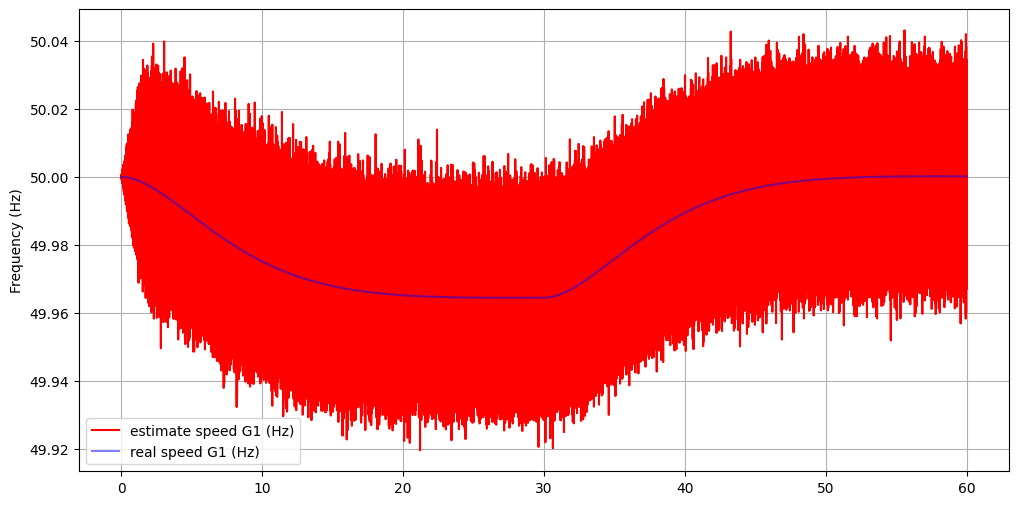

In [19]:
x_hat_final = delta_x_hat_history + x_eq

signal_reel = x_final_history[:, 1] 
signal_estime = (delta_x_hat_history[:, 1] + x_eq[1]) / (2 * np.pi)
erreur = signal_reel - signal_estime
puissance_signal = np.mean(signal_reel**2)
puissance_bruit = np.mean(erreur**2)
snr_estime_db = 10 * np.log10(puissance_signal / puissance_bruit)

print(f"SNR de l'estimation (G1) : {snr_estime_db:.2f} dB")

plt.figure(figsize=(12, 6))
plt.plot(t_steps, x_hat_final[:, 1] / (2*np.pi), 'r', label='estimate speed G1 (Hz)')
plt.plot(t_steps, x_final_history[:, 1], 'b', alpha=0.5, label='real speed G1 (Hz)')
# plt.title("Performance du Filtre de Kalman sur les Écarts")
plt.ylabel("Frequency (Hz)")
plt.legend()
plt.grid(True)
plt.show()